# Lab 1 : Linear Regression

## G3 SDI - Machine Learning

In this lab, we are going to implement linear regression and ridge regression on a medical data example. The data come from a medical study (Stamey et al., 1989), whose goal was to predict the level of prostate-specific antigen (`lpsa`) from some clinical measurements. These clinical exams are carried out before a possible prostatectomy.

The measurements are log cancer volume `lcavol`, log prostate weight `lweight`, age of the patient `age`, log of benign prostatic hyperplasia amount `lbph`, seminal vesicle invasion `svi`, log of capsular penetration `lcp`, Gleason score `gleason`, and percent of Gleason scores 4 or 5 `pgg45`. The variable `svi` is binary, `gleason` is ordinal, others are quantitative.

### Instructions
* Rename your notebook with your surnames as `lab1_Name1_Name2.ipynb`, and include your names in the notebook.
* Your code, and its output, must be commented !
* Please upload your notebook on Moodle in the dedicated section before the deadline.

<div style="background-color: rgba(255, 255, 0, 0.15); padding: 8px;">
Report written by Henry Fernandes--Strag, [name2], date.
</div>

In [1]:
# Import usual libraries
import numpy as np
from matplotlib import pyplot as plt

### Part 1 - Linear regression

In this first part, we focus on using linear regression.

**Q1.** Load the data from the `.npy` files included in the archive (use `np.load`). How many examples are there ? How many features ?

In [2]:
X = np.load("data_X.npy")
Y = np.load("data_Y.npy")

print(X.shape, Y.shape)

(97, 8) (97,)


<div style="background-color: rgba(255, 255, 0, 0.15); padding: 8px;">
From the shape print and the print of the data itself there is 97 examples and 8 features
</div>

**Q2.** Check whether there are some missing entries in the dataset (both in X and y). Use `np.isnan`.

In [3]:
print(np.sum(np.isnan(X)), np.sum(np.isnan(Y)))


0 0


<div style="background-color: rgba(255, 255, 0, 0.15); padding: 8px;">
There is no missing entries as we see from the print of the sum of isnan.
</div>

**Q3.** Divide the dataset into a training set (80%) and a test set (20%), using `train_test_split` with `random_state = 0` (documentation [here](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)).

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state= 0)


**Q4.** Standardize the training set, and apply the same operation to the test set. Use `StandardScaler` (documentation [here](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)). Recall what standardization means.

In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)

print(scaler.mean_)
print(scaler.var_)
X_train = scaler.transform(X_train)

scaler.fit(X_test)
X_test = scaler.transform(X_test);

[ 1.45797770e+00  3.63111404e+00  6.36103896e+01  6.21919622e-02
  2.46753247e-01 -1.20210145e-01  6.77922078e+00  2.40259740e+01]
[1.32534680e+00 1.87359887e-01 5.45495024e+01 2.05977571e+00
 1.85866082e-01 1.94384579e+00 5.87620172e-01 7.91609715e+02]


<div style="background-color: rgba(255, 255, 0, 0.15); padding: 8px;">
Standartiser les données signifie rendre chaque feature de moyenne nulle et de variance nulle, afin d'assurer une répartition équilibrée des features, d'avoir une meilleure stabilité numérique, et de compenser notamment les différences d'ordre de grandeur entre elles. Elle permet une meilleure généralisation de l'apprentissage mené dessus.
</div>

**Q5.** Compute the auto-covariance matrix from the training set, and display it (you might want to use `plt.imshow`). What can we learn from this ?

<Axes: >

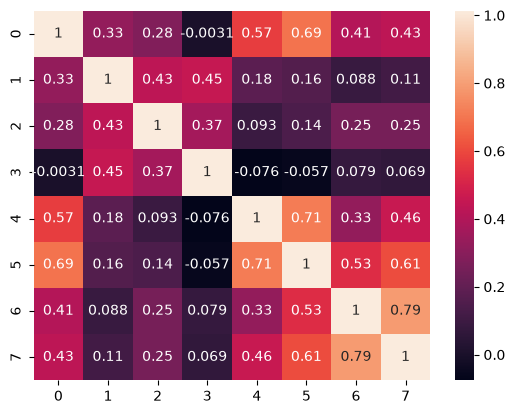

In [6]:
import seaborn as sns

sns.heatmap(np.cov(np.transpose(X_train)), annot = True, cbar = True, fmt = ".2g")

<div style="background-color: rgba(255, 255, 0, 0.15); padding: 8px;">
Ici les features ne sont pas excessivement corrélées entre elles. Les coefficients de la régression devraient être plutôt stables numériquement (peu sensibles à de faibles variations dans les données) du fait de l'absence de collinéarité entre les features.
</div>

**Q6.** We are now going to train the linear regression model using scikit-learn (check the documentation [here](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html)). Use the `.fit` method on the training set. Retrieve the coefficients obtained by scikit-learn using the attributes `.intercept_` and `.coef_`, and check that it corresponds to the closed-form solution from the lecture (you might want to use `np.hstack` to concatenate X with a column of ones).

In [7]:
from sklearn.linear_model import LinearRegression

reg = LinearRegression().fit(X_train, Y_train)
coefs = np.insert(reg.coef_, 0, reg.intercept_) #on rajoute l'intercept pour comparer à la solution analytique
print(coefs)


#on crée un dataset X tilde avec la colonne de 1 supplémentaire pour le calcul de la solution analytique.
X_t_train= np.hstack(((np.ones(shape = (X_train.shape[0], 1))), X_train))

#calcul "à la main" de la solution analytique (on utilise une fonction numpy car c'est possible ici, mais pour le ridge on ne le fera pas !):

Beta = np.dot(np.linalg.pinv(X_t_train), Y_train)

print(Beta)


[ 2.53335755  0.76489178  0.21507901 -0.19817076  0.17007883  0.33767514
 -0.2352964   0.10599694  0.06116098]
[ 2.53335755  0.76489178  0.21507901 -0.19817076  0.17007883  0.33767514
 -0.2352964   0.10599694  0.06116098]


<div style="background-color: rgba(255, 255, 0, 0.15); padding: 8px;">
Les coefficients coincident bien.
</div>

**Q7.** Obtain the model predictions on the test set using the `.predict` method. Then compute the MSE and the MAE (you may want to use the functions below).

In [8]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
Y_pred = reg.predict(X_test)
MSE = mean_squared_error(Y_pred, Y_test)
MAE = mean_absolute_error(Y_pred, Y_test)

print(MSE, MAE)

0.5603540276555412 0.6261843473917168


### Part 2 - Ridge regression

In this second part, we now turn to ridge regression.

**Q1.** Fit the ridge regression model (documentation [here](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html)) with $\lambda = 1$, using the `.fit` method on the training set. Again, retrieve the coefficients, and check that they match with the closed-form solution from the lecture. How do they differ from the ones obtained with linear regression ?

In [9]:
from sklearn.linear_model import Ridge

#on ne s'intéresse pas ici à Beta 0 qui n'est pas pénalisé par la régression. Pour le calcul de la solution analytique des coefficients nous n'allons donc pas ajouter la colonne de 1.
lam = 1
ridge_reg = Ridge(alpha = lam).fit(X_train, Y_train)
print(ridge_reg.coef_)


#calcul "à la main" de la solution analytique :


A = X_train.T @ X_train + lam * np.eye(X_train.shape[1]) #on prend bien shape[1] pour avoir une matrice de même taille que X^T * X (nb de features)
Beta_ridge = np.linalg.inv(A) @ X_train.T @ Y_train

print(Beta_ridge)


[ 0.74219288  0.21604499 -0.18971641  0.16549832  0.32885721 -0.20975118
  0.102791    0.05942405]
[ 0.74219288  0.21604499 -0.18971641  0.16549832  0.32885721 -0.20975118
  0.102791    0.05942405]


<div style="background-color: rgba(255, 255, 0, 0.15); padding: 8px;">
les coefficients coincident bien ici aussi.
</div>

**Q2.** Obtain the model predictions on the test set using the `.predict` method, then compute the MSE and the MAE. Do we get better or worse predictions than before ? Comment.

In [10]:
Ridge_Y_pred = ridge_reg.predict(X_test)
MSE_ridge = mean_squared_error(Ridge_Y_pred, Y_test)
MAE_ridge = mean_absolute_error(Ridge_Y_pred, Y_test)

print(MSE_ridge, MAE_ridge)
print(MSE - MSE_ridge, MAE - MAE_ridge)

0.5466835737482854 0.6230688970877003
0.013670453907255853 0.0031154503040164983


<div style="background-color: rgba(255, 255, 0, 0.15); padding: 8px;">
On obtient une meilleure MSE et une meilleure MAE. C'est attendu car la ridge regression a pour objectif de réduire la variance de notre modèle sans augmenter en pénalisant la contribution d'un grand nombre de coeffients, sans pour autant augmenter trop le biais.
</div>

**Q3.** We are now going to assess the impact of the regularization coefficient $\lambda$.

To do so, vary $\lambda$ from $10^{-3}$ and $10^3$ (use `np.logspace`), and for each value of $\lambda$, retrain the ridge regression model and keep the values of the coefficients (ignoring the intercept).

Display the evolution of the coefficients w.r.t. $\lambda$ (use a logarithmic scale for the x-axis). Comment.

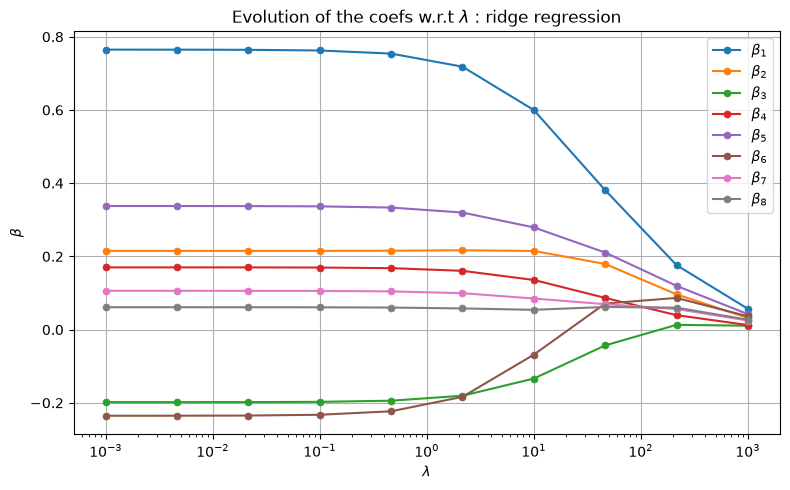

In [11]:
#On va factoriser cette représentation graphique avec une fonction qui génère les arrays nécessaires pour notre plot :

def compare_ridge(X : np.ndarray, Y : np.ndarray, lam_min : float, lam_max : float) -> np.ndarray :
    lambda_space = np.logspace(lam_min, lam_max, 10)
    coef_array = []
    for lam in lambda_space :
        ridge_reg = Ridge(alpha= lam).fit(X,Y)
        coef_array.append(ridge_reg.coef_)

    return lambda_space, np.array(coef_array)

#Nous pouvons maintenant plot l'évolution de chaque coefficient sur un même graphique.

fig, ax = plt.subplots(figsize=(8,5))
lambda_space, all_coefs = compare_ridge(X_train, Y_train, -3, 3)
for i in range(all_coefs.shape[1]):
        ax.plot(lambda_space, all_coefs[:, i],linewidth = 1.5,marker = "o",markersize = 5,markeredgewidth= 0.5,label = rf"$\beta_{i+1}$")

ax.set_ylabel(rf"$\beta$")
ax.set_xlabel(rf"$\lambda$")
ax.set_xscale("log")
ax.legend()
ax.grid()
ax.set_title(rf"Evolution of the coefs w.r.t $\lambda$ : ridge regression")
plt.tight_layout()
plt.show()

<div style="background-color: rgba(255, 255, 0, 0.15); padding: 8px;">
Plus lambda augmente, plus la norme des coefficients est pénalisée et plus ceux-ci convergent vers zéro. beta_1 est davantage réduit en proportion car sa valeur initiale(sans régularisation) est la plus grande : la pénalité du terme de régularisation frappe d'autant plus fort les coefficients de grande amplitude pour permettre une meilleure stabilité du modèle.
</div>

**Q4.** Now remains the question of choosing the optimal $\lambda$. We are going to select it with a 5-fold cross-validation.

Display the evolution of the cross-validated MSE w.r.t. $\lambda$ (use again a logarithmic scale for the x-axis), and display the best $\lambda$ with a `plt.axvline`.

Now retrain the ridge regression model with the selected $\lambda$, and assess its performance in terms of MSE and MAE. Comment.

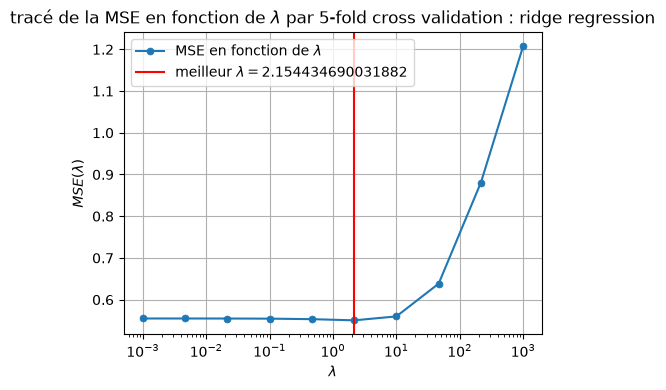

In [ ]:
from sklearn.model_selection import KFold

# Set-up cross-validation
kf = KFold(n_splits=5)
lambda_space = np.logspace(-3, 3, 10)
MSE_comp = []
#boucle sur lamda de la cross validation et calcul de la MSE moyenne :
for lam in lambda_space :
    MSE_lam = 0
    for train_index, val_index in kf.split(X_train):
        X_train_new, X_val = X_train[train_index], X_train[val_index]
        y_train_new, y_val = Y_train[train_index], Y_train[val_index]
        ridge_regs = Ridge(alpha = lam).fit(X_train_new, y_train_new)
        ridge_pred = ridge_regs.predict(X_val)
        MSE_lam += mean_squared_error(y_val, ridge_pred)
    MSE_lam *= 1/5
    MSE_comp.append(MSE_lam)

#calcul du meilleur lambda :
best_idx = np.argmin(MSE_comp)
best_lam = lambda_space[best_idx]

#plot de l'évolution de la MSE en fonction de lambda:
fig, ax = plt.subplots(figsize = (5,4))
ax.plot(lambda_space, MSE_comp, linewidth = 1.5,marker = "o",markersize= 5,markeredgewidth= 0.5,label = rf"MSE en fonction de $\lambda$")
plt.axvline(x = best_lam, color = "r", label = rf"meilleur $\lambda = {best_lam}$")
ax.set_xscale("log")
ax.set_xlabel(rf"$\lambda$")
ax.set_ylabel(rf"$MSE(\lambda)$")
ax.set_title(rf"tracé de la MSE en fonction de $\lambda$ par 5-fold cross validation : ridge regression")
ax.grid()

plt.tight_layout()
plt.legend()
plt.show()

<div style="background-color: rgba(255, 255, 0, 0.15); padding: 8px;">
Dans notre cas, sans régularisation, deux coefficients dominent la régression. Dès lors, dès que le lambda dépasse l'ordre de grandeur de l'unité, on se met à pénaliser des coefficients importants, ce qui nuit à la MSE. Il est donc logique que le lambda optimal soit de l'odre de 1.
</div>

In [13]:
ridge_best = Ridge(alpha = best_lam).fit(X_train, Y_train)
best_pred = ridge_best.predict(X_test)

best_MSE = mean_squared_error(Y_test, best_pred)
best_MAE = mean_absolute_error(Y_test, best_pred)

print(best_MSE-MSE_ridge, best_MAE-MAE_ridge)


-0.013305884628912135 -0.003233799943651139


<div style="background-color: rgba(255, 255, 0, 0.15); padding: 8px;">
La MSE est légérement meilleur pour ce lambda optimal
</div>

### Part 3 (Bonus) - LASSO

Display the same kind of plots as in Part 2, but using LASSO regression instead of ridge regression (see [here](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html). In particular, comment on the following points :
* Do the regression coefficients evolve in the same way as ridge regression ? What kind of solutions do we obtain ?
* Do we get the same optimal lambda ?

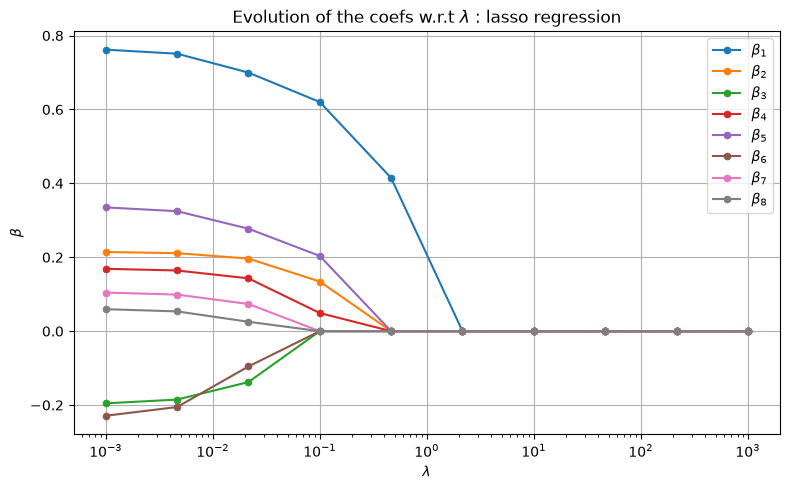

In [14]:
from sklearn.linear_model import Lasso

#bon, on duplique du code, mais c'est plus rapide pour nous !

def compare_lasso(X : np.ndarray, Y : np.ndarray, lam_min : float, lam_max : float) -> np.ndarray :
    lambda_space = np.logspace(lam_min, lam_max, 10)
    coef_array = []
    for lam in lambda_space :
        lasso_reg = Lasso(alpha= lam).fit(X,Y)
        coef_array.append(lasso_reg.coef_)

    return lambda_space, np.array(coef_array)

fig, ax = plt.subplots(figsize=(8,5))
lambda_space, all_coefs = compare_lasso(X_train, Y_train, -3, 3)
for i in range(all_coefs.shape[1]):
        ax.plot(lambda_space, all_coefs[:, i],linewidth = 1.5,marker = "o",markersize = 5,markeredgewidth= 0.5,label = rf"$\beta_{i+1}$")

ax.set_ylabel(rf"$\beta$")
ax.set_xlabel(rf"$\lambda$")
ax.set_xscale("log")
ax.legend()
ax.grid()
ax.set_title(rf"Evolution of the coefs w.r.t $\lambda$ : lasso regression")
plt.tight_layout()
plt.show()

<div style="background-color: rgba(255, 255, 0, 0.15); padding: 8px;">
Les coefficients de la régression convergent plus rapidement vers 0, pour finalement s'y annuler complétement. Pour lambda > 1, il ne subsiste qu'un seul coefficient de régression.
</div>

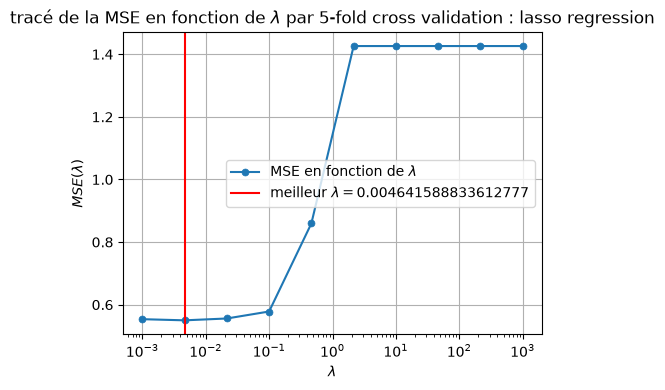

In [15]:
# Set-up cross-validation
kf = KFold(n_splits=5)
lambda_space = np.logspace(-3, 3, 10)
MSE_comp = []
for lam in lambda_space :
    MSE_lam = 0
    for train_index, val_index in kf.split(X_train):
        X_train_new, X_val = X_train[train_index], X_train[val_index]
        y_train_new, y_val = Y_train[train_index], Y_train[val_index]
        lasso_regs = Lasso(alpha = lam).fit(X_train_new, y_train_new)
        lasso_pred = lasso_regs.predict(X_val)
        MSE_lam +=  mean_squared_error(y_val, lasso_pred)
    MSE_lam *= 1/5
    MSE_comp.append(MSE_lam)

best_idx = np.argmin(MSE_comp)
best_lam = lambda_space[best_idx]

fig, ax = plt.subplots(figsize = (5,4))
ax.plot(lambda_space, MSE_comp, linewidth = 1.5,marker = "o",markersize= 5,markeredgewidth= 0.5,label = rf"MSE en fonction de $\lambda$")
plt.axvline(x = best_lam, color = "r", label = rf"meilleur $\lambda = {best_lam}$")
ax.set_xscale("log")
ax.set_xlabel(rf"$\lambda$")
ax.set_ylabel(rf"$MSE(\lambda)$")
ax.set_title(rf"tracé de la MSE en fonction de $\lambda$ par 5-fold cross validation : lasso regression")
ax.grid()

plt.tight_layout()
plt.legend()
plt.show()

<div style="background-color: rgba(255, 255, 0, 0.15); padding: 8px;">
Le lambda optimal est bien plus faible. Une regression lasso est par conséquent moins utile dans ce cas présent. Cela s'explique par le fait que dans notre cas, sans régularisation, seulement deux coefficients dominent la régression. Le lasso, qui tend à annuler les coefficients les plus faibles, ne peut qu'augmenter la MSE s'il se met à annuler des coefficients importants, d'où la croissance subite dès que le lambda devient un minimum conséquent (0.1). 
Cette méthode de régularisation privéligie la simplicité du modèle, au détriment du biais.
</div>

In [16]:
lasso_best = Lasso(alpha = best_lam).fit(X_train, Y_train)
best_lasso_pred = lasso_best.predict(X_test)

best_lasso_MSE = mean_squared_error(Y_test, best_lasso_pred)
best_lasso_MAE = mean_absolute_error(Y_test, best_lasso_pred)

lasso_normal = Lasso(alpha = 1).fit(X_train, Y_train)
normal_lasso_pred = lasso_normal.predict(X_test)

normal_lasso_MSE = mean_squared_error(Y_test, normal_lasso_pred)
normal_lasso_MAE = mean_absolute_error(Y_test, normal_lasso_pred)

print(best_lasso_MSE-normal_lasso_MSE, best_lasso_MAE-normal_lasso_MAE)

-0.605424064054503 -0.27031308651788877


<div style="background-color: rgba(255, 255, 0, 0.15); padding: 8px;">
On constate que le choix du lambda importe plus pour le lasso dans notre exmemple; choisir un mauvais lambda peut conduire à un modèle trop grossier et donc mauvais
</div>